# Comparación jerárquica de modelos entrenados

Este notebook carga **todos** los modelos entrenados en `artifacts/models/` (uno por
nivel de agregación M5: total, dept, store, store×dept) y compara sus predicciones
sobre el mismo período de test.

La pregunta de fondo: para un nivel de agregación dado (p.ej. el total de ventas),
¿es mejor pronosticarlo **directamente** con el modelo entrenado en ese nivel, o
**sumarlo (bottom-up)** a partir de las predicciones de un modelo entrenado en un
nivel más fino (dept, store, store×dept)? Y de paso, ¿combinar ambos enfoques
mejora el resultado?

Estructura:
1. Carga de artifacts + reconstrucción de test set + predicciones.
2. Tabla resumen de cada modelo en su propio nivel nativo.
3. Comparación al nivel **TOTAL**: modelo L1 directo vs. bottom-up desde L4/L6/L9,
   + una combinación simple (promedio) de todos.
4. Comparación a niveles intermedios: **dept** (L4 directo vs. bottom-up desde L9)
   y **store** (L6 directo vs. bottom-up desde L9).


In [41]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from src.data.split import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape
from src.evaluation.scaled import compute_naive_scales


## 0. Comparativo

In [109]:
artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
print(f"Artifacts encontrados: {[p.name for p in artifact_paths]}")

comparative = {}
for artifact_path in artifact_paths:
    artifact = joblib.load(artifact_path)
    comparative[f"L{artifact['level_id']}"] = {
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
    }

df_comparative = pd.DataFrame(comparative).T

df_comparative

Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl']


,wape_test,wrmsse_test
L1,0.059545,0.579390
L2,0.058795,0.549077
L3,0.056743,0.493992
L4,0.065183,0.596292
L5,0.069812,0.589583
L6,0.073069,0.613509


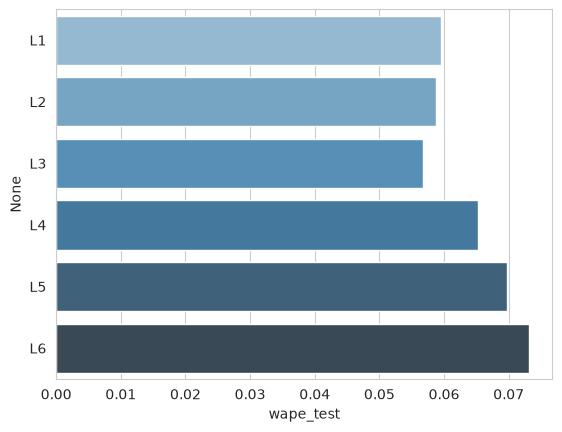

In [113]:
sns.barplot(
    data=df_comparative,
    x="wape_test",
    hue=df_comparative.index,
    y=df_comparative.index,
    palette="Blues_d"
)
plt.show()

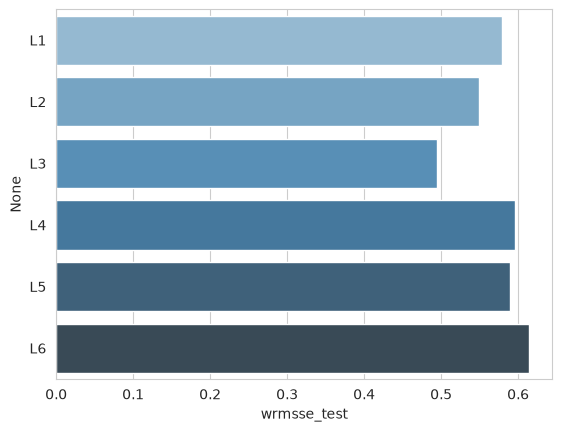

In [114]:
sns.barplot(
    data=df_comparative,
    x="wrmsse_test",
    hue=df_comparative.index,
    y=df_comparative.index,
    palette="Blues_d"
)
plt.show()

## 1. Carga de artifacts, reconstrucción de test y predicciones

## 1.1 Carga

In [ ]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]

def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
        "train": train,
        "dims_available": dims_available,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_id"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


2026-09-04 18:12:46.511 | INFO     | __main__:<module>:33 - Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl']
2026-09-04 18:12:46.762 | INFO     | src.data.split:load_data:359 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)
2026-09-04 18:12:46.777 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 1,885 rows)
2026-09-04 18:12:46.780 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 28 rows)
2026-09-04 18:12:46.782 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)
2026-09-04 18:12:47.253 | INFO     | src.data.split:split_data:421 - Features: 182 (9 categóricas)
2026-09-04 18:12:47.350 | INFO     | __m

## 2. Resumen de cada modelo en su propio nivel nativo

In [43]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_id": level_id,
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_id")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


,level,n_series,modelo,wape,wrmsse,bias,rmse
level_id,,,,,,,
1,level_01_daily_total,1,FittedModel,5.95%,0.579,-5.79%,"3,425.8"
2,level_02_daily_state,3,FittedModel,5.88%,0.549,-4.83%,"1,193.6"
3,level_03_daily_cat,3,FittedModel,5.67%,0.494,-4.96%,"1,405.6"
4,level_04_daily_dept,7,FittedModel,6.52%,0.596,-4.58%,663.3
5,level_05_daily_state_cat,9,FittedModel,6.98%,0.590,-4.07%,570.9
6,level_06_daily_store,10,FittedModel,7.31%,0.614,-4.99%,443.7


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
diaria total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. También se arma una combinación simple: el
promedio de las 4 predicciones totales, como primer paso hacia una reconciliación
jerárquica más formal (bottom-up ya está acá; top-down por proporciones históricas
o MinT/optimal reconciliation -- p.ej. con `hierarchicalforecast` -- quedan como
extensión natural).

In [44]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


# Solo se agregan al total los niveles que particionan por completo la serie total
# (item/item_store, 10-12, están filtrados a un subconjunto dept/store y no sumarían al total real).
VALID_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

total_aggs = {
    level_id: aggregate_to_total(res["df_pred"])
    for level_id, res in LEVELS.items()
    if level_id in VALID_LEVELS
}

df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
for level_id, agg in sorted(total_aggs.items()):
    df_total[f"L{level_id}"] = agg["y_pred"]

# combinación naive: promedio de las predicciones de todos los niveles disponibles
pred_cols = [c for c in df_total.columns if c != "actual"]
#df_total["Promedio de niveles"] = df_total[pred_cols].mean(axis=1)

df_total.round(0).head()

,actual,L1,L2,L3,L4,L5,L6
date,,,,,,,
2016-04-25,38793.0,37991.0,38033.0,36351.0,37305.0,36733.0,36902.0
2016-04-26,35487.0,34635.0,34293.0,34245.0,34638.0,34827.0,34167.0
2016-04-27,34445.0,33544.0,33248.0,34441.0,33562.0,34354.0,33513.0
2016-04-28,34732.0,33585.0,34817.0,34634.0,34755.0,35540.0,34178.0
2016-04-29,42896.0,43934.0,41829.0,40913.0,39869.0,41391.0,42644.0


In [45]:
# Escala WRMSSE del total: MSE del naive de 1 día in-sample sobre el train del
# nivel L1 (la serie total ya es una sola serie -- no hay ponderación entre grupos).
train_total = LEVELS[1]["train"][["date", "sales"]].copy()
train_total["series_id"] = "TOTAL"
scale_total = compute_naive_scales(train_total, group_col="series_id", target_col="sales")["TOTAL"]

rows = []
for col in [c for c in df_total.columns if c != "actual"]:
    y_true, y_pred = df_total["actual"], df_total[col]
    rows.append({
        "enfoque": col,
        "wape": wape(y_true, y_pred),
        "bias": bias(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "wrmsse": rmse(y_true, y_pred) / np.sqrt(scale_total),
    })

df_total_metrics = pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)
df_total_metrics

,enfoque,wape,bias,rmse,wrmsse
0,L4,0.048401,-0.045833,2780.672394,0.470289
1,L2,0.048453,-0.048315,2946.517769,0.498338
2,L5,0.048569,-0.040728,2709.618417,0.458272
3,L3,0.052763,-0.049630,2928.898769,0.495358
4,L6,0.053024,-0.049861,3055.423252,0.516757
5,L1,0.059544,-0.057858,3425.698792,0.579381


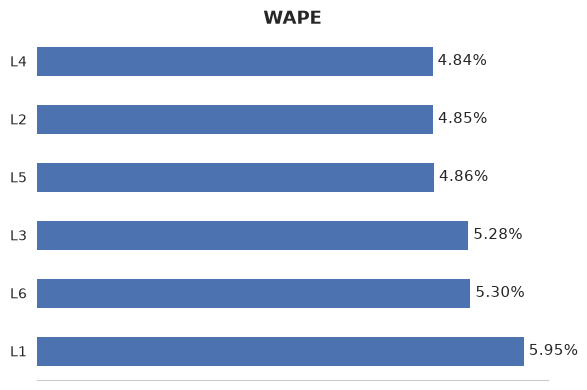

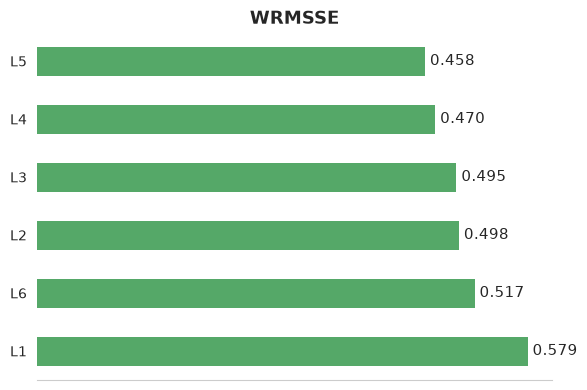

In [67]:
import matplotlib.pyplot as plt

df_plot = df_total_metrics.set_index("enfoque")

metrics = {"wape": ("WAPE", "%"), "wrmsse": ("WRMSSE", "num")}
colors = {"wape": "#4C72B0", "bias": "#DD8452", "wrmsse": "#55A868"}

for metric, (title, fmt_type) in metrics.items():
    sort_type = False if metric in ["wape", "wrmsse"] else False
    data = df_plot[metric].sort_values(ascending=sort_type)

    fig, ax = plt.subplots(figsize=(6, 4))
    data.plot(kind="barh", ax=ax, color=colors[metric], edgecolor="none")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xticks([])

    for i, v in enumerate(data):
        label = f"{v:.2%}" if fmt_type == "%" else f"{v:.3f}"
        ax.text(v, i, f" {label}", va="center", fontsize=11)

    plt.tight_layout()
    plt.grid(False)
    plt.show()

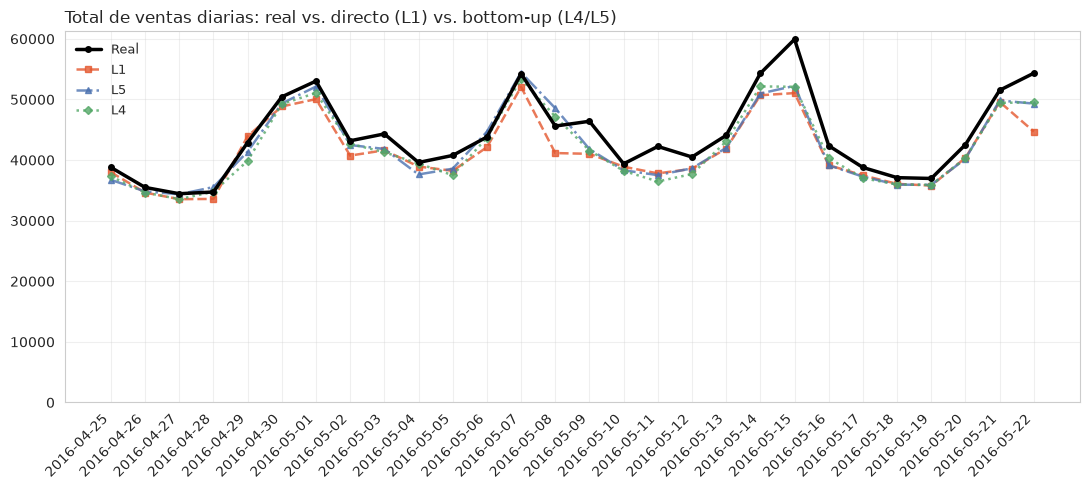

In [91]:
df_plot = df_total[['actual', 'L1', 'L5', 'L4']].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_plot.index, df_plot["actual"], label="Real", color="black",
        linewidth=2.5, marker="o", markersize=4, zorder=3)

styles = [
    {"color": "#E4572E", "linestyle": "--", "marker": "s"},
    {"color": "#4C72B0", "linestyle": "-.", "marker": "^"},
    {"color": "#55A868", "linestyle": ":", "marker": "D"},
]

for col, style in zip([c for c in df_plot.columns if c != "actual"], styles):
    ax.plot(df_plot.index, df_plot[col], label=col, alpha=0.8,
            linewidth=1.8, markersize=4, zorder=2, **style)

ax.set_title("Total de ventas diarias: real vs. directo (L1) vs. bottom-up (L4/L5)", loc="left")
ax.set_xlabel("")
ax.set_xticks(df_plot.index)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.ylim(0)
plt.show()

## Conclusiones rápidas

- Revisar `df_total_metrics`: si "Promedio de niveles" queda por debajo del mejor
  enfoque individual, hay señal de que combinar información de distintos niveles
  de agregación reduce error -- la motivación estándar detrás de la reconciliación
  jerárquica (bottom-up, top-down, MinT).
- `df_dept_compare` / `df_store_compare` (columna `gana_bottomup`) muestran, serie
  por serie, si conviene más el modelo especializado en ese nivel o la suma desde
  el nivel más fino -- normalmente depende de cuánta señal específica del grupo
  (dept/store) exista vs. cuánta información se gana de tener series individuales
  más finas para el modelo de L9.
- Extensión natural: formalizar esto con reconciliación óptima (p.ej.
  `hierarchicalforecast` de Nixtla, que ya cubre bottom-up/top-down/MinT sobre esta
  misma estructura de niveles).
